In [2]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import OneHotEncoder

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.tree import DecisionTreeRegressor

from matplotlib import pyplot as plt

from sklearn.metrics import r2_score

In [6]:
path = 'pre_processed (1).pkl'

df = pd.read_pickle(path)

In [7]:
df.shape

(8465, 16)

In [8]:
df.columns

Index(['Date', 'Rented Bike Count', 'Hour', 'Temperature(°C)', 'Humidity(%)',
       'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)',
       'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Seasons',
       'Day', 'Month', 'Year', 'Weekend_or_Holiday'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8465 entries, 0 to 8759
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Date                       8465 non-null   datetime64[ns]
 1   Rented Bike Count          8465 non-null   int64         
 2   Hour                       8465 non-null   category      
 3   Temperature(°C)            8465 non-null   float64       
 4   Humidity(%)                8465 non-null   int64         
 5   Wind speed (m/s)           8465 non-null   float64       
 6   Visibility (10m)           8465 non-null   int64         
 7   Dew point temperature(°C)  8465 non-null   float64       
 8   Solar Radiation (MJ/m2)    8465 non-null   float64       
 9   Rainfall(mm)               8465 non-null   float64       
 10  Snowfall (cm)              8465 non-null   float64       
 11  Seasons                    8465 non-null   category      
 12  Day        

In [10]:
categorical_cols = ['Hour', 'Seasons', 'Day', 'Month', 'Year', 'Weekend_or_Holiday']

encoder = OneHotEncoder(drop='first', sparse_output=False)

X_cat = encoder.fit_transform(df[categorical_cols])

cat_feature_names = encoder.get_feature_names_out(categorical_cols)

In [11]:
numerical_cols = ['Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)',
                  'Visibility (10m)', 'Dew point temperature(°C)',
                  'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)']

X_num = df[numerical_cols].values

In [12]:
X_encoded = np.hstack([X_num, X_cat])

feature_names = np.concatenate([numerical_cols, cat_feature_names])

In [13]:
y = df['Rented Bike Count'].values

In [14]:
print(f"{X_encoded.shape}")
print(f"{y.shape}")

(8465, 77)
(8465,)


In [15]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

In [16]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(6772, 77)
(1693, 77)
(6772,)
(1693,)


In [17]:
dt = DecisionTreeRegressor(random_state=42)

In [18]:
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10]
}

In [19]:
grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=3
)

In [20]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 80 candidates, totalling 400 fits


GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [3, 5, 7, 10, None],
                         'min_samples_leaf': [1, 2, 5, 10],
                         'min_samples_split': [2, 5, 10, 20]},
             scoring='r2', verbose=3)

In [22]:
best_dt = grid_search.best_estimator_
print("Best parameters:", grid_search.best_params_)

Best parameters: {'max_depth': None, 'min_samples_leaf': 5, 'min_samples_split': 20}


In [23]:
y_pred = best_dt.predict(X_test)

In [24]:
r2 = r2_score(y_test, y_pred)
print("Test set R²:", r2)

Test set R²: 0.8393055787767468


In [25]:
feature_importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': best_dt.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importances.head(15))  # top 15 features

                      Feature  Importance
0             Temperature(°C)    0.360508
1                 Humidity(%)    0.153044
25                    Hour_18    0.088713
5     Solar Radiation (MJ/m2)    0.042664
76       Weekend_or_Holiday_1    0.038296
26                    Hour_19    0.035582
29                    Hour_22    0.035094
27                    Hour_20    0.028430
28                    Hour_21    0.027403
15                     Hour_8    0.026965
24                    Hour_17    0.026755
33             Seasons_Winter    0.023690
6                Rainfall(mm)    0.014363
30                    Hour_23    0.014273
4   Dew point temperature(°C)    0.011073


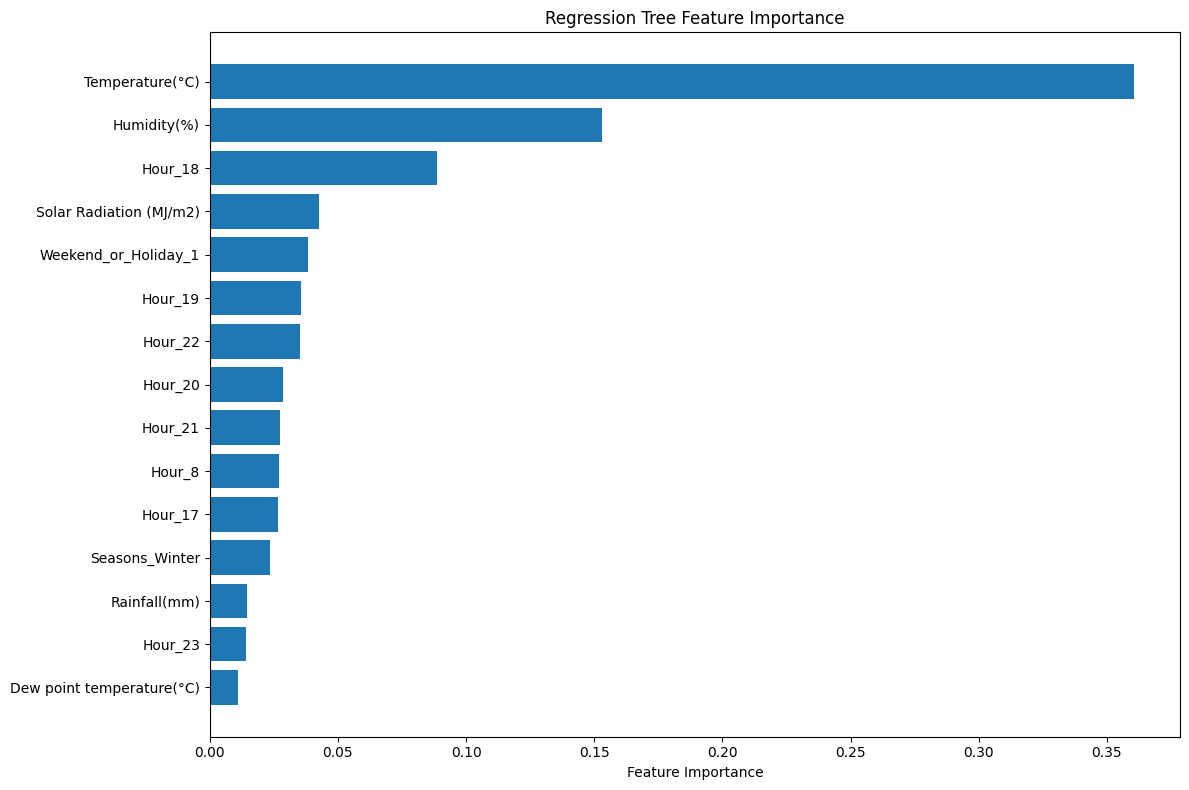

In [26]:
plt.figure(figsize=(12, 8))
top_features = feature_importances.head(15)
plt.barh(top_features['Feature'], top_features['Importance'])
plt.xlabel('Feature Importance')
plt.title('Regression Tree Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()